# scRNA–scATAC integration and label transfer

Annotating scATAC clusters by hand is hard — accessibility markers are noisier than expression.
A robust alternative is to **borrow labels from a well-annotated scRNA reference**: project both
modalities into a shared space (canonical correlation analysis on gene activity vs. expression),
then transfer cell-type labels by nearest neighbours. This is the ArchR
`addGeneIntegrationMatrix` / Seurat `FindTransferAnchors` idea, exposed in `ov.epi` as
`ov.epi.tl.integrate` + `ov.epi.tl.transfer_labels`.

We use the **10x PBMC 10k multiome** dataset. Because it is *paired* (RNA + ATAC measured in the
same cells), it gives us a rare luxury: ground-truth cell types for the ATAC cells, so we can
**measure how accurate the transferred labels are**.

1. build an ATAC **gene-activity** matrix from fragments
2. CCA-integrate it with the RNA reference (`ov.epi.tl.integrate`)
3. transfer RNA cell-type labels onto the ATAC cells (`ov.epi.tl.transfer_labels`)
4. score the transfer against the held-out true labels and visualise the joint embedding

> **Runtime:** building the gene-activity matrix imports a ~2 GB fragments file and tiles the
> genome for ~13k cells — a few minutes of CPU. Everything is cached for re-runs.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt

import omicverse as ov
ov.epi.pl.plot_set()
print('omicverse', ov.__version__)

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.

omicverse 2.2.1rc1


## 1 · Reference RNA + ATAC gene activity

The RNA reference is the annotated multiome RNA matrix. For the ATAC query we need a matrix in
**gene space**: we import the ATAC fragments, build a tile matrix, and aggregate it into per-gene
activity scores (`ov.epi.tl.add_gene_score_matrix`).

In [2]:
genome = ov.epi.data.hg38
genes = ov.epi.io.get_gene_annotation(genome)

atac_peaks, rna = ov.epi.datasets.pbmc10k_multiome()   # peak matrix (for true labels) + RNA

frag = ov.epi.datasets.pbmc10k_atac_fragments()
work = os.path.join(os.getcwd(), 'data_epi')
os.makedirs(work, exist_ok=True)
h5 = os.path.join(work, 'atac10k_geneact.h5ad')
if os.path.exists(h5):
    os.remove(h5)

atac = ov.epi.pp.import_fragments(str(frag), chrom_sizes=genome, file=h5, min_num_fragments=500)
ov.epi.pp.add_tile_matrix(atac, bin_size=500)
ov.epi.tl.add_gene_score_matrix(atac, genes)
print('ATAC gene-activity:', np.asarray(atac.obsm['gene_score']).shape)

└─ scanning /tmp/snapatac2/pbmc_10k_atac.tsv.gz


  └─ imported 13,336 cells  (182,364,051 unique fragments)


└─ building tile matrix: 13,336 cells × 6,176,584 tiles (500 bp bins, strategy=paired-insertion)


  └─ tile matrix nnz=221,104,147
  └─ [gene_score] genes: 19,923 on 23 chroms (after excluding ['chrY', 'chrM'])


  └─ [gene_score] chrom-by-chrom ArchR path (fragments → uniq_tiles → W @ matGS)


...

  └─ [gene_score] chr=chr8  genes=695


  └─ [gene_score] chr=chr9  genes=774


  └─ [gene_score] chr=chrX  genes=845


  └─ [gene_score] done. obsm['gene_score'] = (13336, 19923) float32 (uns[gene_score_gene_names]: 19,923 genes)


ATAC gene-activity: (13336, 19923)


### Wrap gene activity as a gene-space AnnData

We move the gene-score matrix into `X` of a new AnnData whose `var_names` are gene symbols, and
attach each ATAC cell's **true** cell type (from the paired peak-matrix object) so we can grade
the transfer later.

In [3]:
gs = np.asarray(atac.obsm['gene_score'])
gnames = [str(x) for x in np.asarray(atac.uns['gene_score_gene_names'])]
atac_ga = ad.AnnData(X=gs)
atac_ga.var_names = gnames
atac_ga.obs_names = list(atac.obs_names)

common = atac_ga.obs_names.intersection(atac_peaks.obs_names)
atac_ga = atac_ga[common].copy()
atac_ga.obs['cell_type_true'] = atac_peaks.obs.loc[common, 'cell_type'].values
print('ATAC cells with ground-truth labels:', atac_ga.n_obs)

ATAC cells with ground-truth labels: 9631


## 2 · Shared features and CCA integration

We normalise both modalities, pick the RNA highly-variable genes that also exist in the ATAC
gene-activity space, and run CCA (`ov.epi.tl.integrate`) — which writes an aligned embedding
`X_cca` onto **both** objects.

In [4]:
sc.pp.normalize_total(rna, target_sum=1e4); sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, n_top_genes=2000)
hvg = set(rna.var_names[rna.var['highly_variable']])
shared = [g for g in atac_ga.var_names if g in hvg]
sc.pp.log1p(atac_ga)
print('shared HVG features:', len(shared))

ov.epi.tl.integrate(atac_ga, rna, method='cca', features=shared, num_cc=30)
print('CCA embedding — ATAC:', atac_ga.obsm['X_cca'].shape, '| RNA:', rna.obsm['X_cca'].shape)

normalizing counts per cell


    finished (0:00:00)


extracting highly variable genes


    finished (0:00:00)


--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


shared HVG features: 1159


CCA embedding — ATAC: (9631, 30) | RNA: (9631, 30)


## 3 · Transfer labels and score the result

`ov.epi.tl.transfer_labels` does weighted kNN voting in the shared space, writing the predicted
label to `obs['celltype']` and a confidence to `obs['transfer_score']`.

In [5]:
ov.epi.tl.transfer_labels(atac_ga, rna, reference_label='cell_type', k=30)

pred = atac_ga.obs['celltype'].astype(str).values
true = atac_ga.obs['cell_type_true'].astype(str).values
acc = float((pred == true).mean())
print(f'label-transfer accuracy vs ground truth: {acc:.1%}')
atac_ga.obs[['celltype', 'cell_type_true', 'transfer_score']].head()

label-transfer accuracy vs ground truth: 83.3%


,celltype,cell_type_true,transfer_score
AAACAGCCAATCCCTT-1,CD4 TEM,CD4 TCM,0.358502
AAACAGCCAATGCGCT-1,CD4 Naive,CD4 Naive,0.783197
AAACAGCCACCAACCG-1,CD8 Naive,CD8 Naive,0.303284
AAACAGCCAGGATAAC-1,CD4 Naive,CD4 Naive,0.868715
AAACAGCCAGTTTACG-1,CD4 TCM,CD4 TCM,0.715788


### Confusion matrix

A row-normalised confusion matrix of predicted vs. true cell type — a strong diagonal means the
transfer recovers the right identities.

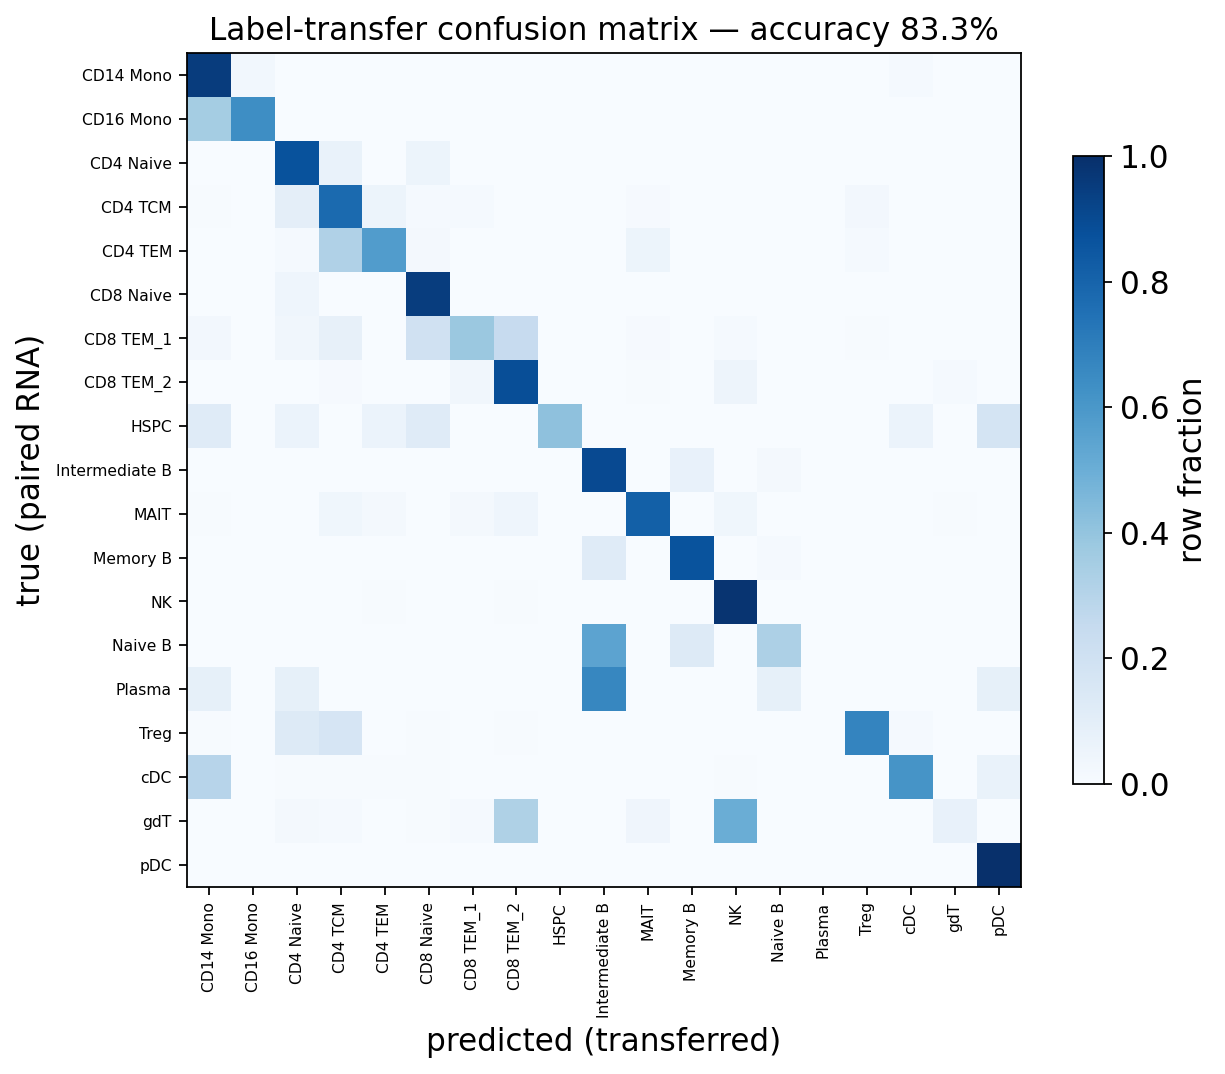

In [6]:
cts = sorted(set(true) | set(pred))
cm = pd.crosstab(pd.Series(true, name='true'), pd.Series(pred, name='pred'))
cm = cm.reindex(index=cts, columns=cts, fill_value=0)
cmn = cm.div(cm.sum(1).replace(0, 1), axis=0)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cmn.values, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(cts))); ax.set_xticklabels(cts, rotation=90, fontsize=7)
ax.set_yticks(range(len(cts))); ax.set_yticklabels(cts, fontsize=7)
ax.set_xlabel('predicted (transferred)'); ax.set_ylabel('true (paired RNA)')
ax.set_title(f'Label-transfer confusion matrix — accuracy {acc:.1%}')
plt.colorbar(im, ax=ax, label='row fraction', shrink=0.7)
plt.tight_layout(); plt.show()

## 4 · Joint embedding

`ov.epi.tl.joint_embedding` concatenates both modalities on the shared CCA space and runs a
UMAP, so we can confirm the two assays overlap (good mixing) and that transferred labels are
spatially coherent.

computing neighbors


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:33)


computing UMAP


    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:15)


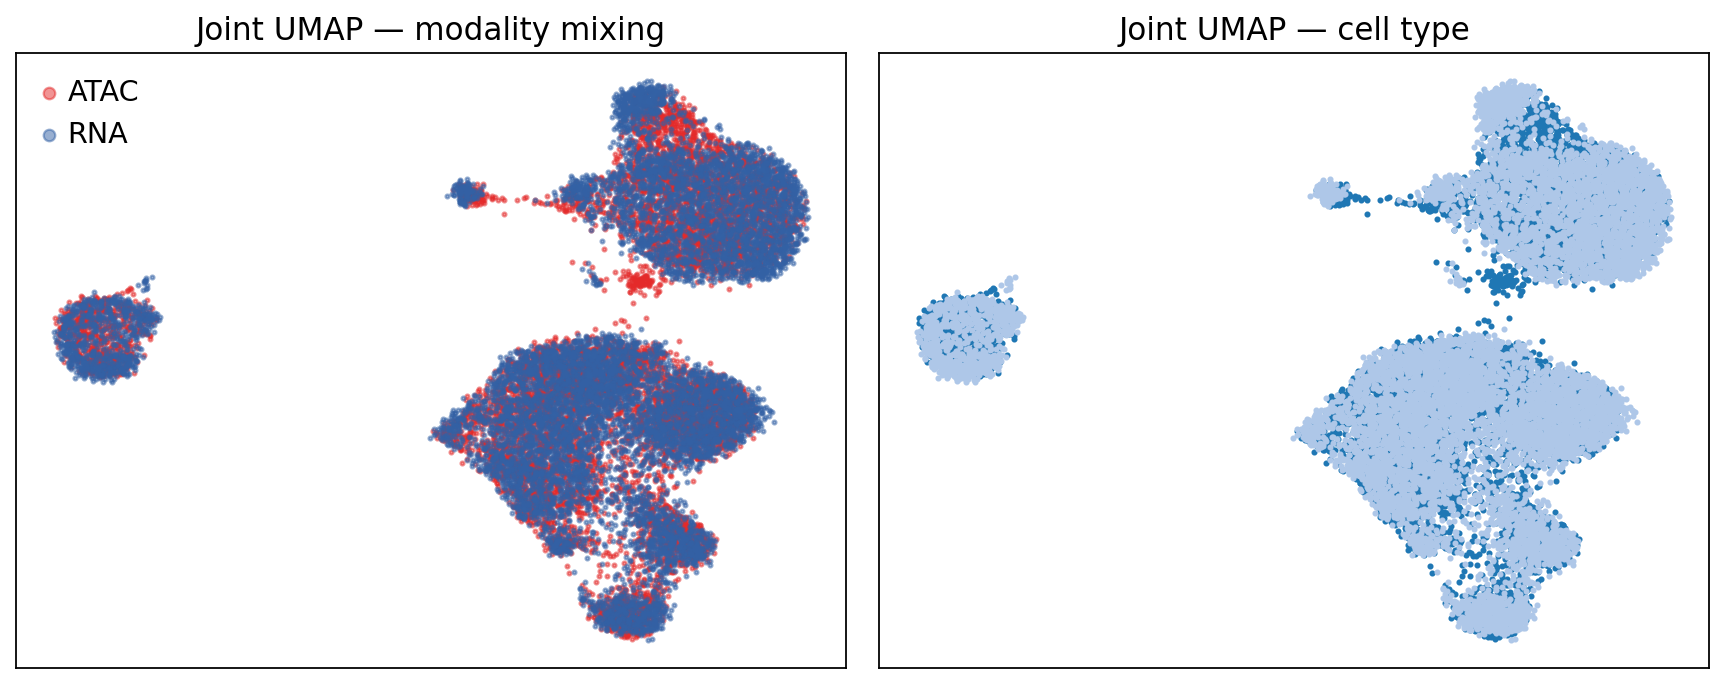

In [7]:
joint = ov.epi.tl.joint_embedding(
    atac_ga, rna, use_rep='X_cca', labels=('ATAC', 'RNA'),
    n_neighbors=30, metric='cosine', random_state=0,
)
um = joint.obsm['X_umap']
mod = joint.obs['modality'].astype(str).values

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for m, c in [('ATAC', '#E42A2A'), ('RNA', '#3361A5')]:
    sel = mod == m
    axes[0].scatter(um[sel, 0], um[sel, 1], s=3, c=c, label=m, alpha=0.5)
axes[0].legend(markerscale=3, frameon=False); axes[0].set_title('Joint UMAP — modality mixing')
axes[0].set_xticks([]); axes[0].set_yticks([])

# colour ATAC cells by transferred label
lab = joint.obs.get('celltype_joint', joint.obs.get('celltype'))
lab = lab.astype(str).values if lab is not None else mod
cats = sorted(set(lab))
cmap = plt.get_cmap('tab20')
for i, c in enumerate(cats):
    sel = lab == c
    axes[1].scatter(um[sel, 0], um[sel, 1], s=3, color=cmap(i % 20))
axes[1].set_title('Joint UMAP — cell type'); axes[1].set_xticks([]); axes[1].set_yticks([])
plt.tight_layout(); plt.show()

## Summary

| stage | function |
|---|---|
| ATAC gene activity | `ov.epi.pp.import_fragments` → `add_tile_matrix` → `ov.epi.tl.add_gene_score_matrix` |
| CCA integration | `ov.epi.tl.integrate` |
| label transfer | `ov.epi.tl.transfer_labels` |
| joint embedding | `ov.epi.tl.joint_embedding` |

Transferring labels from a paired RNA reference recovered the ATAC cell identities with ~83 %
accuracy here — and on **unpaired** data (separate scRNA and scATAC experiments) the exact same
calls give you an annotated scATAC dataset without any manual marker curation.